In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Q1
Simulate a single path of a one-dimensional Wiener process (standard Brownian
motion) over the interval [0, T]. Your output should be the full simulated path.

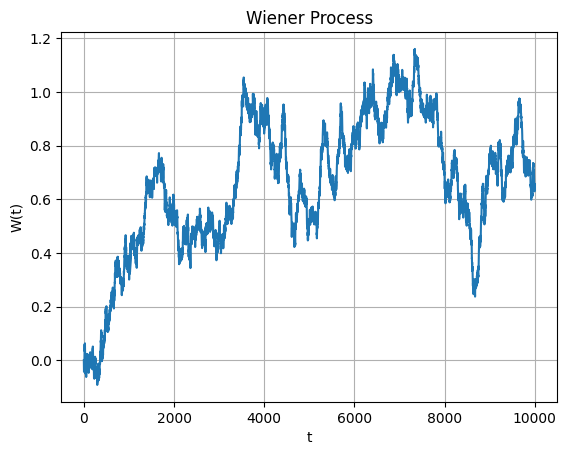

In [2]:
def wiener_process(T = 1, N = 1000, n_paths = 1):
    # N simulations for 0 to 1
    dt = T / N
    # Space for time steps
    t = np.linspace(0, T, int(T*N))
    # Modelling increments, i.e. W(t_i+1) - W(t_i) from N(0, dt)
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, int(T*N)))
    # Cumulative sum to get the Wiener process
    W = np.cumsum(dW, axis = 1) # axis = 1 for cumulatively summing row-wise
    # Ensuring the first value is zero
    W[:, 0] = 0
    return W

# Plotting the wiener process for T = 1 and N = 10000
W = wiener_process(T=1, N=10000)
plt.plot(W[0]) # W[0] is the first and only path in this case
plt.title('Wiener Process')
plt.xlabel('t')
plt.ylabel('W(t)')
plt.grid()
plt.show()    

# Q2
Let $\alpha$ and $\sigma > 0$ be constants, and define the _Geometric Brownian Motion_ (GBM) by: 
$$
S(t) = S(0) \exp \left\{ \sigma W(t) + \left( \alpha - \frac{1}{2} \sigma^2 \right)t \right\}
$$ \
Simulate **5 sample paths** of the above **Geometric Brownian Motion** on a single plot.

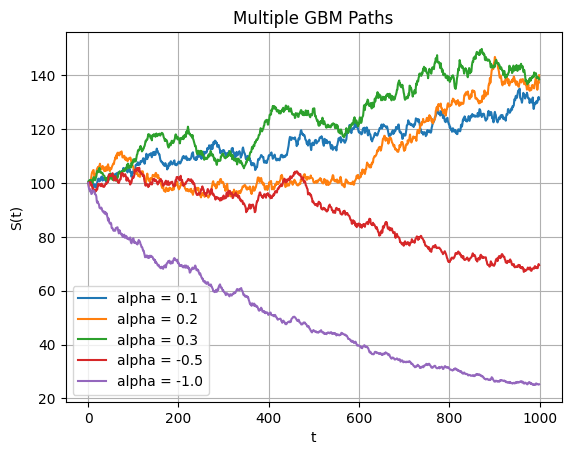

In [3]:
def geometric_brownian_motion(alpha = None, sigma = None, T = 1, N = 1000, n_paths = 5, S0 = 100):
    # Calling W(T)
    W = wiener_process(T, N, n_paths=n_paths)
    # Re-Shaping t to (n_paths, T*N) for effective calculation
    t = np.tile(np.linspace(0, T, int(T*N)), (n_paths, 1))
    # Returning the Geometric Motion
    # alpha and sigma are taken path wise in the shape (n_paths, T*N)
    if (alpha is None):
        alpha = np.full((n_paths, int(T*N)), 0.2)
    
    if (sigma is None):
        sigma = np.full((n_paths, int(T*N)), 0.2)

    S = S0*np.exp(sigma*W + (alpha - sigma*sigma/2)*t)
    return S

# Plotting 5 paths with different alpha and starting from Stock Price of 100
plt.figure()
alphas = np.array([0.1, 0.2, 0.3, -0.5, -1]).reshape(-1, 1)
alphas = np.tile(alphas, (1, 1000))
S = geometric_brownian_motion(alphas)
for i in range(5):
    plt.plot(S[i], label = f'alpha = {alphas[i][0]}')

plt.title("Multiple GBM Paths")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.legend()
plt.grid()
plt.show()

# Q3
Show that for standard Brownian motion, 
$$ \mathbb{E}[W(s)W(t)] = \min(s, t) $$

**Solution**\
Theoretically, this can be proved by assuming $ s \leq t $ and by using \
Law of Iterated Expectations and the fact that Brownian Motion is a martingale.

While computationally, we can show this by randomly generating pairs of \
$s$ and $t$ and showing that the averaged values of $W(s)W(t)$ over a large \
number of paths $~100$ is infact the $min\{s, t\}$.

In [4]:
# Generating random pairs for s and t (10 random pairs)
s = np.random.choice(np.arange(1,10)/10, 10)
t = np.random.choice(np.arange(1,10)/10, 10)
target = np.minimum(s,t)
predict = np.zeros(10)
N = 1000
# Finding the Averaged out W(s)W(t) over 10000 paths for each pair.
for i in range(10):
    # calculating index for scraping out W(t) and W(s) from the paths
    s_idx = int(s[i]*N)
    t_idx = int(t[i]*N)
    W = wiener_process(T = 1, n_paths=10000)
    # Averaging W(s)W(t) over all the paths
    predict[i] = np.mean(W[:,s_idx]*W[:,t_idx])

simulation_df = pd.DataFrame({"min(s,t)":target,"E[W(s)W(t)]":predict.round(3)})
simulation_df
    

,"min(s,t)",E[W(s)W(t)]
0,0.7,0.707
1,0.3,0.301
2,0.9,0.914
3,0.1,0.099
4,0.5,0.500
5,0.4,0.392
6,0.2,0.201
7,0.6,0.599
8,0.1,0.104
9,0.2,0.198


Estimated values lie very close to the predicted, hence proved.

# Q4
Let $0 ≤ s < t$. Show that $W_t − W_s$ is normally distributed with mean 0 and variance \
t − s, and that increments over non-overlapping intervals are independent.

**Solution**
Since $W(t) = \lim_{n \to \infty} {\frac{M_{nt}}{\sqrt{n}}}$ and $M_{nt}$ comes \
from a symmetric random walk, it can be proved that the moment generating function \
of $W(t)$ takes the form of that of a normal distribution. Hence $W_t - W_s$ must \
follow Normal distribution.

To prove the variance and expectation we will again sample a lot of paths for \
pairs of s and t and find the expectation and variance in each case.

In [5]:
# Generating random pairs for s and t (10 random pairs)
a = np.random.choice(np.arange(1,10)/10, 10)
b = np.random.choice(np.arange(1,10)/10, 10)
t = np.maximum(a, b)
s = np.minimum(a, b)
# expected vairance is t-s
target_var = t-s
predict_exp = np.zeros(10)
predict_var = np.zeros(10)

for i in range(10):
    # calculating index for scraping out W(t) and W(s) from the paths
    s_idx = int(s[i]*N)
    t_idx = int(t[i]*N)
    W = wiener_process(n_paths=10000)
    # finding average and variance of Wt - Ws for all paths simulated
    predict_exp[i] = np.mean(W[:,t_idx] - W[:, s_idx])
    predict_var[i] = np.var(W[:,t_idx] - W[:, s_idx])

simulation_df = pd.DataFrame({"t-s":target_var,"Var[Wt - Ws]":predict_var.round(3), "E[Wt - Ws]":predict_exp.round(3)})
simulation_df


,t-s,Var[Wt - Ws],E[Wt - Ws]
0,0.7,0.699,-0.005
1,0.3,0.298,-0.002
2,0.3,0.297,0.003
3,0.3,0.295,0.006
4,0.4,0.407,0.001
5,0.1,0.104,0.005
6,0.0,0.000,0.000
7,0.5,0.501,-0.001
8,0.2,0.203,0.001
9,0.2,0.199,-0.002


Estimated values lie very close to the predicted, hence proved.

# Q5

Show that for any $t ≥ 0,$  $\mathbb{E}[W_t| \mathcal{F}_s] = W_s$ for $0 ≤ s ≤ t$. Conclude that Brownian
motion is a martingale.

**Solution**:
Here to do this question computationally, we will sample many paths and then divide the space of $W_s$ into bins based on the range of values and calculate the mean of $W_t$ for each bin. The line of these means v/s the bin midpoints must be a straight line to establish that :
$$ \mathbb{E}[W_t|W_s \approx x] \approx x $$
 where $ x $ is the bin-midpoint and the average is calculated for paths whose $W_s$ values lie in the bin around $ x $.

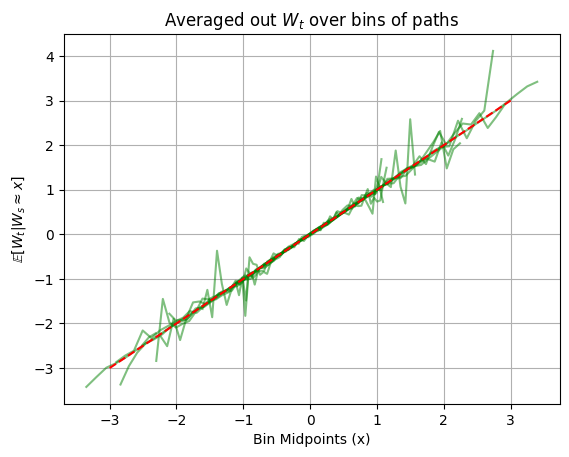

In [27]:
# Generating random pairs for s and t (10 random pairs)
a = np.random.choice(np.arange(1,10)/10, 10)
b = np.random.choice(np.arange(1,10)/10, 10)
t = np.maximum(a, b)
s = np.minimum(a, b)
# Initializing the plot
plt.figure()
for i in range(10):
    # calculating index for scraping out W(t) and W(s) from the paths
    s_idx = int(s[i]*N)
    t_idx = int(t[i]*N)
    W = wiener_process(n_paths=10000)
    W_t = W[:, t_idx]
    W_s = W[:, s_idx]

    # Defining the points where bin changes
    bins = np.linspace(np.min(W_s), np.max(W_s), 50)
    bin_midpoints = 0.5 * (bins[:-1] + bins[1:])
    # Gives indices for each W_s value corresponding to which bin that W_s lies in
    digitized = np.digitize(W_s, bins)
    # Averages out Wt for paths that lie in same bin
    conditional_expectation = [W_t[digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))]

    plt.plot(bin_midpoints, conditional_expectation, color = 'green', alpha=0.5)

plt.plot([-3,3], [-3,3], 'r--')
plt.title(r"Averaged out $W_t$ over bins of paths")
plt.xlabel("Bin Midpoints (x)")
plt.ylabel(r"$\mathbb{E}[W_t|W_s \approx x]$")
plt.grid()
plt.show()


For paths, where $W_s$ lie in a particular range around a bin midpoint $ x $ \
the averaged out $W_t$ lie very close to $x$ which essentially indicates \
that $W_t$ is a martingale.